<a href="https://colab.research.google.com/github/alysonbz/NLP/blob/larissa/AV2_NLP_LLM_larissa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Avaliação 2

In [1]:
import pandas as pd
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import torch
import ast

# Carregando os dados
coment_sem_tratamento = pd.read_csv("/content/drive/MyDrive/content_sem_trat.csv")
print("Dataset bruto:\n")
print(coment_sem_tratamento.head())
coment_pre_process = pd.read_csv("/content/drive/MyDrive/content_lemmatized_stemmed.csv")
print("\nDataset tratado:\n")
print(coment_pre_process.head())

# Distribuição das classes em ambos datasets
print(coment_sem_tratamento['score'].value_counts())
print(coment_pre_process['score'].value_counts())

# Verifica se há GPU disponível e define o dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definindo o modelo e o tokenizer
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

# Função para aplicar LLM no dataset
def classify_with_llm(texts, batch_size=16):
    preds = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():  # Desativa o cálculo de gradientes
            predictions = model(**inputs)
        preds.extend(torch.argmax(predictions.logits, dim=1).tolist())
    return preds

# Treinamento do modelo
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    save_steps=10_000,
    save_total_limit=2,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=...  # Crie um Dataset PyTorch a partir dos seus dados
)

trainer.train()

# Aplicar a LLM no dataset sem pré-processamento
raw_texts = coment_sem_tratamento['content'].tolist()
y_true = coment_sem_tratamento['score'].tolist()
y_pred_raw = classify_with_llm(raw_texts)

# Métricas de avaliação sem pré-processamento
print("\nResultados sem pré-processamento:")
print(classification_report(y_true, y_pred_raw))
print(confusion_matrix(y_true, y_pred_raw))

# Ajuste no pré-processamento
processed_texts = [ast.literal_eval(tokens) for tokens in coment_pre_process['content_lemmatized'].tolist()]
processed_texts = [' '.join(tokens) for tokens in processed_texts]

y_pred_processed = classify_with_llm(processed_texts)

# Métricas de avaliação com pré-processamento
print("\nResultados com pré-processamento:")
print(classification_report(y_true, y_pred_processed))
print(confusion_matrix(y_true, y_pred_processed))

# Verificando as classes preditas
print("Classes preditas (sem pré-processamento):", set(y_pred_raw))
print("Classes preditas (com pré-processamento):", set(y_pred_processed))


Dataset bruto:

   id                                            content  score
0   0  All that was on there were people from Africa....      0
1   1  Not free soon as you send message up pops the ...      0
2   2  This app has the worst "floating" notification...      0
3   3  Terrible ! Full of scams and they can't even m...      0
4   4  My profile was deleted twice and i have no ide...      0

Dataset tratado:

   id                                            content  \
0   0  All that was on there were people from Africa....   
1   1  Not free soon as you send message up pops the ...   
2   2  This app has the worst "floating" notification...   
3   3  Terrible ! Full of scams and they can't even m...   
4   4  My profile was deleted twice and i have no ide...   

                                     content_stemmed  \
0  ['peopl', 'africa', 'profil', 'said', 'local',...   
1  ['free', 'soon', 'send', 'messag', 'pop', 'got...   
2  ['app', 'worst', 'float', 'notif', 'cannot', '...

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model che


Resultados sem pré-processamento:
              precision    recall  f1-score   support

           0       0.30      0.03      0.06      5000
           1       0.49      0.92      0.64      5000

    accuracy                           0.48     10000
   macro avg       0.39      0.48      0.35     10000
weighted avg       0.39      0.48      0.35     10000

[[ 168 4832]
 [ 392 4608]]

Resultados com pré-processamento:
              precision    recall  f1-score   support

           0       0.51      0.07      0.12      5000
           1       0.50      0.93      0.65      5000

    accuracy                           0.50     10000
   macro avg       0.51      0.50      0.39     10000
weighted avg       0.51      0.50      0.39     10000

[[ 345 4655]
 [ 326 4674]]
Classes preditas (sem pré-processamento): {0, 1}
Classes preditas (com pré-processamento): {0, 1}


### Com treinamento específico

In [1]:
import pandas as pd
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import classification_report, confusion_matrix
import torch
import ast
from torch.utils.data import Dataset

# Carregando os dados
coment_sem_tratamento = pd.read_csv("/content/drive/MyDrive/content_sem_trat.csv")
print("Dataset bruto:\n")
print(coment_sem_tratamento.head())
coment_pre_process = pd.read_csv("/content/drive/MyDrive/content_lemmatized_stemmed.csv")
print("\nDataset tratado:\n")
print(coment_pre_process.head())

# Distribuição das classes em ambos datasets
print(coment_sem_tratamento['score'].value_counts())
print(coment_pre_process['score'].value_counts())

# Verifica se há GPU disponível e define o dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Definindo o modelo e o tokenizer
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)
model.to(device)

# Classe para o Dataset
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        # Tokenização
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            return_token_type_ids=False,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt',
            truncation=True
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Definindo o tamanho máximo dos textos
max_length = 512

# Criando o Dataset para os dados sem pré-processamento
raw_texts = coment_sem_tratamento['content'].tolist()
raw_labels = coment_sem_tratamento['score'].tolist()
train_raw_dataset = TextDataset(raw_texts, raw_labels, tokenizer, max_length)

# Criando o Dataset para os dados pré-processados
processed_texts = [ast.literal_eval(tokens) for tokens in coment_pre_process['content_lemmatized'].tolist()]
processed_texts = [' '.join(tokens) for tokens in processed_texts]
processed_labels = coment_pre_process['score'].tolist()
train_processed_dataset = TextDataset(processed_texts, processed_labels, tokenizer, max_length)

# Configurando os parâmetros de treinamento
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    save_steps=10_000,
    save_total_limit=2,
)

# Treinamento para dados sem pré-processamento
trainer_raw = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_raw_dataset
)
trainer_raw.train()

# Treinamento para dados com pré-processamento
trainer_processed = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_processed_dataset
)
trainer_processed.train()

# Função para aplicar LLM no dataset
def classify_with_llm(texts, batch_size=16):
    preds = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():  # Desativa o cálculo de gradientes
            predictions = model(**inputs)
        preds.extend(torch.argmax(predictions.logits, dim=1).tolist())
    return preds

# Aplicar a LLM no dataset sem pré-processamento
y_true = coment_sem_tratamento['score'].tolist()
y_pred_raw = classify_with_llm(raw_texts)

# Métricas de avaliação sem pré-processamento
print("\nResultados sem pré-processamento:")
print(classification_report(y_true, y_pred_raw))
print(confusion_matrix(y_true, y_pred_raw))

# Aplicar a LLM no dataset com pré-processamento
y_pred_processed = classify_with_llm(processed_texts)

# Métricas de avaliação com pré-processamento
print("\nResultados com pré-processamento:")
print(classification_report(y_true, y_pred_processed))
print(confusion_matrix(y_true, y_pred_processed))

# Verificando as classes preditas
print("Classes preditas (sem pré-processamento):", set(y_pred_raw))
print("Classes preditas (com pré-processamento):", set(y_pred_processed))


Dataset bruto:

   id                                            content  score
0   0  All that was on there were people from Africa....      0
1   1  Not free soon as you send message up pops the ...      0
2   2  This app has the worst "floating" notification...      0
3   3  Terrible ! Full of scams and they can't even m...      0
4   4  My profile was deleted twice and i have no ide...      0

Dataset tratado:

   id                                            content  \
0   0  All that was on there were people from Africa....   
1   1  Not free soon as you send message up pops the ...   
2   2  This app has the worst "floating" notification...   
3   3  Terrible ! Full of scams and they can't even m...   
4   4  My profile was deleted twice and i have no ide...   

                                     content_stemmed  \
0  ['peopl', 'africa', 'profil', 'said', 'local',...   
1  ['free', 'soon', 'send', 'messag', 'pop', 'got...   
2  ['app', 'worst', 'float', 'notif', 'cannot', '...

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of DistilBertForSequenceClassification were not initialized from the model che

Step,Training Loss
500,0.274800
1000,0.179200
1500,0.122600


Step,Training Loss
500,0.232100
1000,0.170100
1500,0.120900



Resultados sem pré-processamento:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      5000
           1       0.98      0.98      0.98      5000

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

[[4901   99]
 [ 104 4896]]

Resultados com pré-processamento:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      5000
           1       0.97      0.99      0.98      5000

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

[[4867  133]
 [  61 4939]]
Classes preditas (sem pré-processamento): {0, 1}
Classes preditas (com pré-processamento): {0, 1}


### Matrizes de correlação

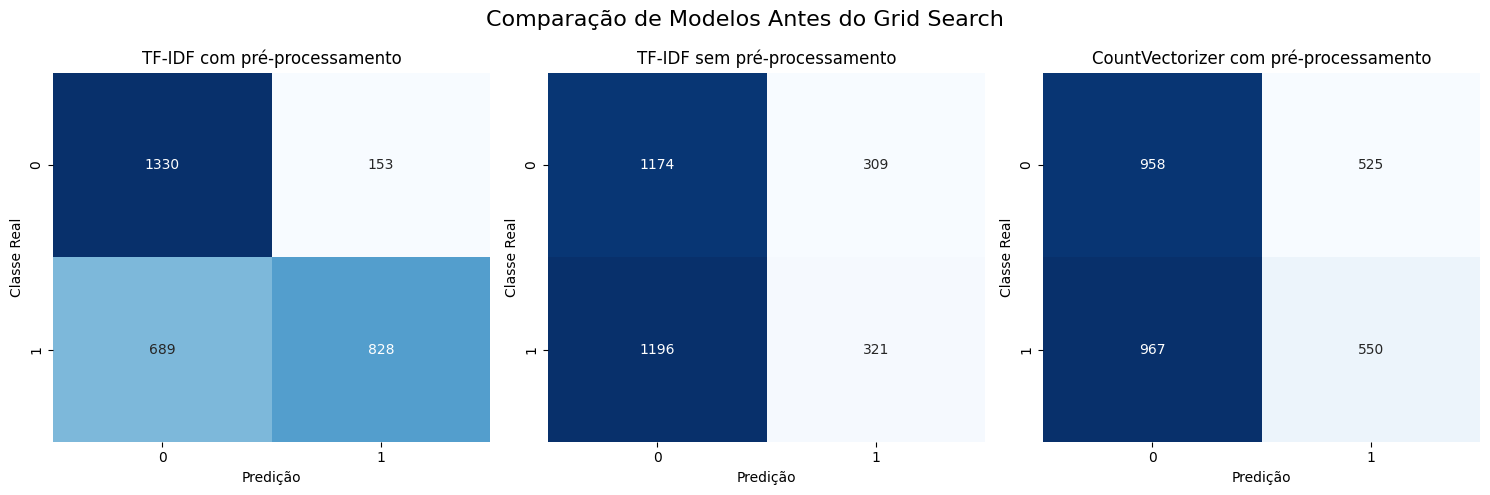

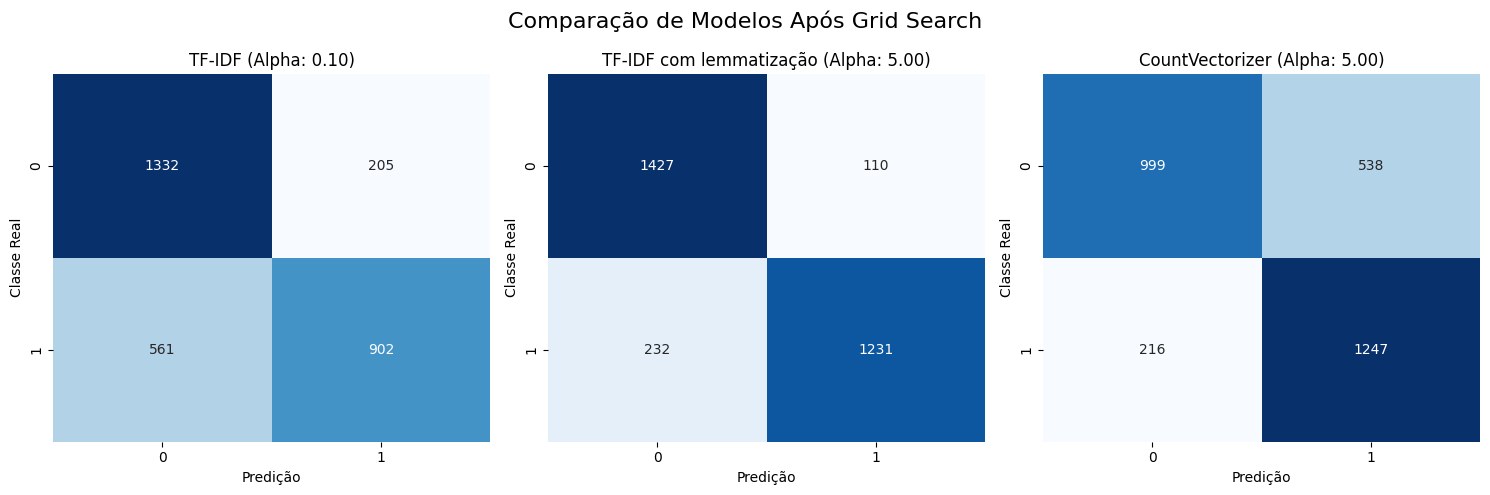

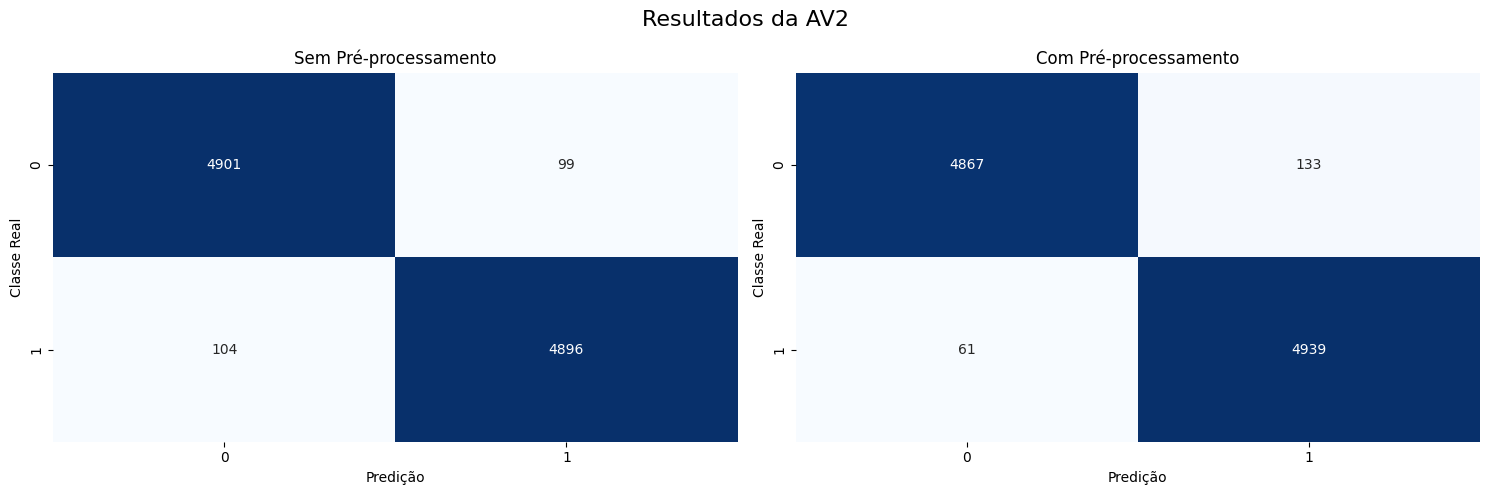

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Dados para as matrizes de confusão
matrizes_antes_grid = [
    np.array([[1330, 153], [689, 828]]),  # TF-IDF com pré-processamento
    np.array([[1174, 309], [1196, 321]]),  # TF-IDF sem pré-processamento
    np.array([[958, 525], [967, 550]])  # CountVectorizer com pré-processamento
]

matrizes_apos_grid = [
    np.array([[1332, 205], [561, 902]]),  # TF-IDF com pré-processamento (Alpha: 0.10)
    np.array([[1427, 110], [232, 1231]]),  # TF-IDF com lemmatização (Alpha: 5.00)
    np.array([[999, 538], [216, 1247]])  # CountVectorizer com pré-processamento (Alpha: 5.00)
]

matrizes_av2 = [
    np.array([[4901, 99], [104, 4896]]),  # Sem pré-processamento
    np.array([[4867, 133], [61, 4939]])  # Com pré-processamento
]

# Função para plotar matrizes de confusão lado a lado
def plot_matrices(matrizes, titulos, titulo_principal):
    fig, axes = plt.subplots(1, len(matrizes), figsize=(15, 5))
    fig.suptitle(titulo_principal, fontsize=16)
    for i, (matrix, title) in enumerate(zip(matrizes, titulos)):
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i])
        axes[i].set_title(title)
        axes[i].set_xlabel('Predição')
        axes[i].set_ylabel('Classe Real')
    plt.tight_layout()
    plt.show()

# Plotando as matrizes antes do Grid Search
plot_matrices(matrizes_antes_grid,
              ['TF-IDF com pré-processamento', 'TF-IDF sem pré-processamento', 'CountVectorizer com pré-processamento'],
              'Comparação de Modelos Antes do Grid Search')

# Plotando as matrizes após o Grid Search
plot_matrices(matrizes_apos_grid,
              ['TF-IDF (Alpha: 0.10)', 'TF-IDF com lemmatização (Alpha: 5.00)', 'CountVectorizer (Alpha: 5.00)'],
              'Comparação de Modelos Após Grid Search')

# Plotando as matrizes da AV2
plot_matrices(matrizes_av2,
              ['Sem Pré-processamento', 'Com Pré-processamento'],
              'Resultados da AV2')
